In [3]:
import pandas as pd
import numpy as np

In [ ]:
# df = pd.read_csv(path_folder + files[0])
df = pd.read_csv('preprocessing_data.csv')
df.head()

In [ ]:
df.drop(columns=['Unnamed: 0','Link','data_stopword','data_lemma','data_token'], inplace=True, errors='ignore')
print(df.columns)

In [ ]:
df.head()

#Membaca Sentimen dari Isi Berita (data_clean)

In [ ]:
import pandas as pd
from transformers import pipeline
import os

# 1. Load Model
model_checkpoint = "mmhhz/model-indobert"
classifier = pipeline("text-classification", model=model_checkpoint)

def get_sentiment_details(teks):
    if pd.isna(teks) or teks == '':
        return "NEUTRAL", 0.0

    hasil = classifier(str(teks)[:512])

    label = hasil[0]['label']
    score_pc = round(hasil[0]['score'] * 100, 2)

    return label, score_pc

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("mmhhz/model-indobert")

teks_contoh = df['data_clean'].iloc[0]
tokens = tokenizer.tokenize(teks_contoh)
token_ids = tokenizer.encode(teks_contoh)

print(f"Teks asli  : {teks_contoh[:150]}...")
print(f"Jumlah token: {len(tokens)}")
print(f"\nHasil token:")
print(tokens)

In [ ]:
# 3. Eksekusi ke Dataframe menggunakan .apply(pd.Series)
print("Sedang melabeli data berita... ")

# Buat kolom baru
df[['sentimen', 'nilai_akurasi']] = df['data_clean'].apply(
    lambda x: pd.Series(get_sentiment_details(x))
)

print("Selesai memberikan label!")

In [10]:
df.head()

,Headline,Tanggal,Isi Berita,teks_gabung,data_clean,detokenization,sentimen,nilai_akurasi
0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,Kepolisian Daerah (Polda) Metro Jaya menutup t...,7 Capaian Polda Metro Sepanjang 2025. Kepolisi...,capaian polda metro sepanjang kepolisian daera...,capai polda metro polisi daerah polda metro ja...,POSITIVE,99.81
1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,Gibran Angkat Bicara soal Pembangunan IKN. Pem...,gibran angkat bicara soal pembangunan ikn pemb...,gibran angkat bicara bangun ikn bangun kota nu...,NEUTRAL,99.94
2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,Kunjungan wisatawan mancanegara ke Bali meleji...,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",kunjungan wisman ke bali melejit saat nataru t...,kunjung wisman bal lejit nataru turis australi...,NEUTRAL,99.95
3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...","China Tegaskan Niat Reunifikasi, Taiwan Bertek...",china tegaskan niat reunifikasi taiwan berteka...,china tegas niat reunifikasi taiwan tekad merd...,NEUTRAL,99.93
4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,Kehadiran Presiden Prabowo Subianto di lokasi ...,Kehadiran Negara dan Efektivitas Penanganan Be...,kehadiran negara dan efektivitas penanganan be...,hadir negara efektivitas tangan bencana hadir ...,POSITIVE,60.90


In [11]:
df.to_csv('labeling_dataset.csv')

#EDA

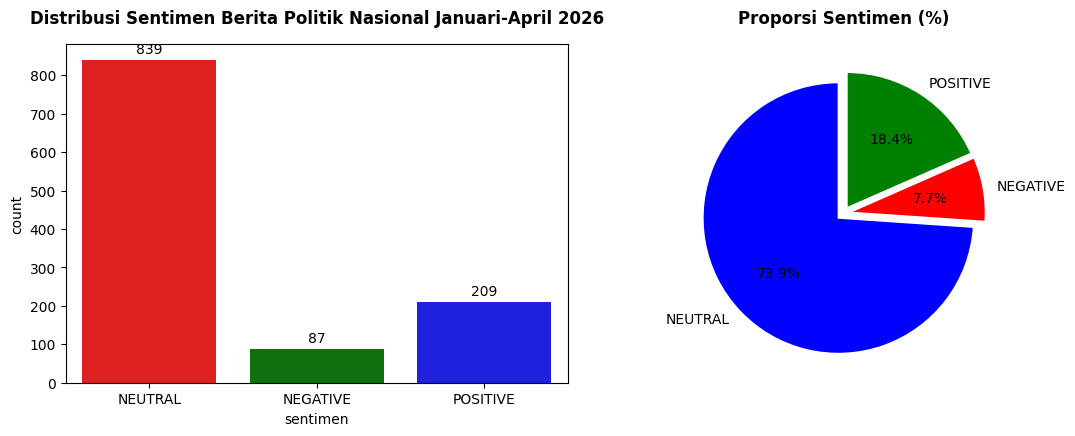

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


categories = [ 'NEUTRAL','NEGATIVE','POSITIVE']
my_colors=['blue','red','green']
color_dict = dict(zip(categories, my_colors))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Card1:Bar Chart
sns.countplot(x='sentimen', data=df, ax=ax1, order=categories, palette=my_colors, hue='sentimen', legend=False)
for container in ax1.containers:
    ax1.bar_label(container, padding=3)

ax1.set_title('Distribusi Sentimen Berita Politik Nasional Januari-April 2026', pad=15, fontweight='bold')


# Card2:Pie Chat
counts = df['sentimen'].value_counts().reindex(categories)
ax2.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=my_colors, 
    startangle=90,
    explode=[0.05] * len(categories),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

ax2.set_title('Proporsi Sentimen (%)', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout(pad=3.0)
plt.show()


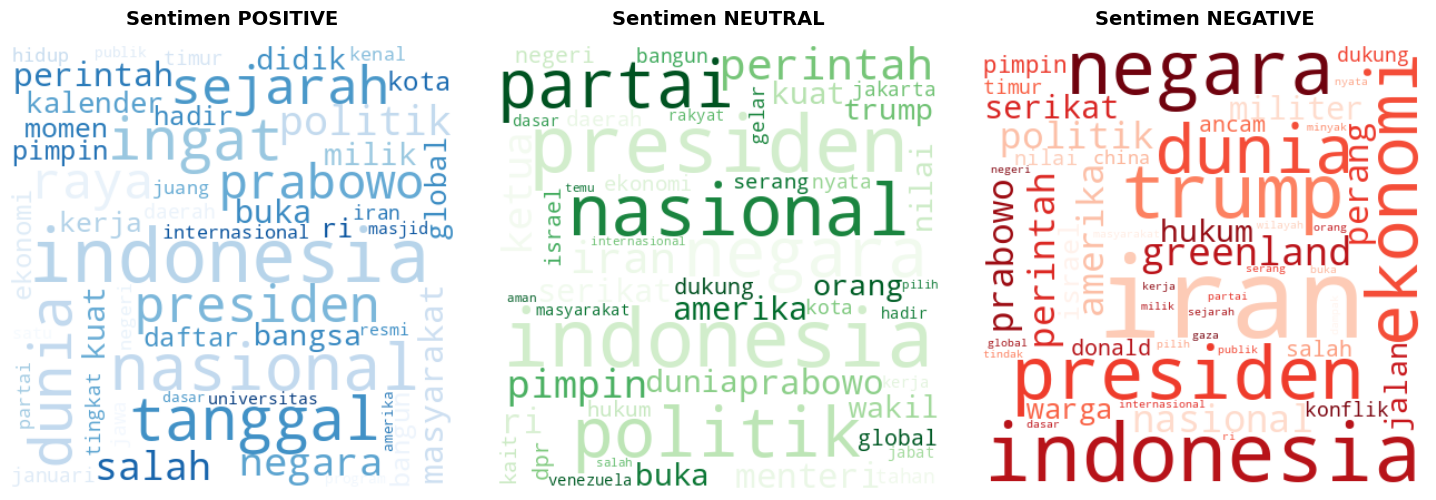

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


categories = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
color_maps = ['Blues', 'Greens', 'Reds'] 


fig, axes = plt.subplots(1, 3, figsize=(15, 7))

for i, cat in enumerate(categories):
    text_data = " ".join(df[df['sentimen'] == cat]['detokenization'].astype(str))

    # Generate WordCloud
    wc = WordCloud(
        width=400,
        height=400,
        background_color='white',
        colormap=color_maps[i],
        max_words=50,
        collocations=False # Menghindari pengulangan kata yang sama dalam pasangan
    ).generate(text_data)


    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Sentimen {cat}', fontsize=14, fontweight='bold', pad=15)
    axes[i].axis("off") 


    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(2)

plt.tight_layout(pad=3.0)
plt.show()

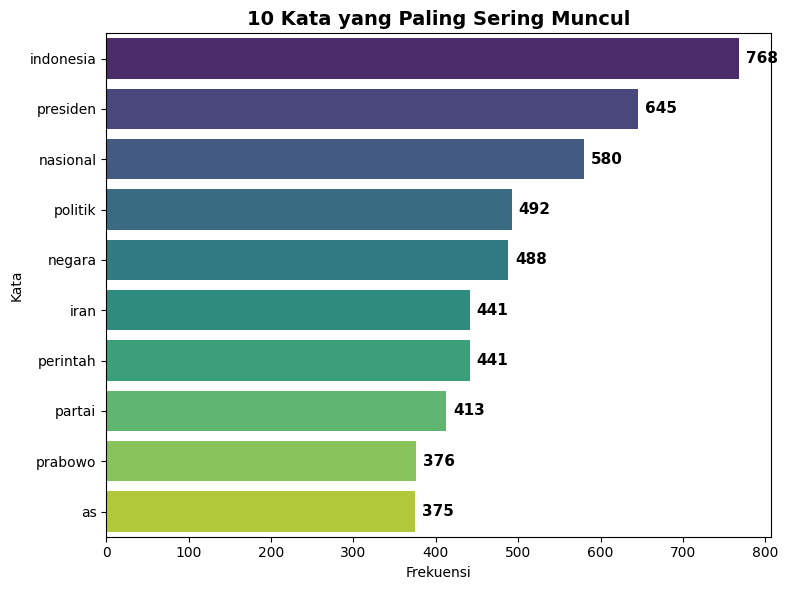

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter


semua_teks = " ".join(df['detokenization'].astype(str))

list_kata = semua_teks.split()
word_counts = Counter(list_kata)
top_10 = word_counts.most_common(10)
kata, jumlah = zip(*top_10)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=list(jumlah), y=list(kata), palette='viridis', hue=list(kata), legend=False)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

plt.title("10 Kata yang Paling Sering Muncul", fontsize=14, fontweight='bold')
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(text, n=2, top_k=10, title="Top Bigrams", color='viridis'):

    if len(text) < 1:
        print(f"Data untuk {title} kosong.")
        return

    vec = CountVectorizer(ngram_range=(n, n)).fit(text)
    bag_of_words = vec.transform(text)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    words, counts = zip(*words_freq)

    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x=list(counts), y=list(words), palette=color)
    ax = sns.barplot(x=list(counts), y=list(words), palette=color, hue=list(words), legend=False)

    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

    plt.title(title, fontsize=10, fontweight='bold', pad=15)
    plt.xlabel('Frekuensi Muncul')
    plt.ylabel('Pasangan Kata (Bigram)')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

# 1. Bigram NEUTRAL
neu_text = df[df['sentimen'] == 'NEUTRAL']['detokenization']
plot_top_ngrams(neu_text, n=2, title="Top 10 Bigram - NEUTRAL", color='Greens_r')

# 2. Bigram NEGATIVE
neg_text = df[df['sentimen'] == 'NEGATIVE']['detokenization']
plot_top_ngrams(neg_text, n=2, title="Top 10 Bigram - NEGATIVE", color='Reds_r')

# 3. Bigram POSITIVE
pos_text = df[df['sentimen'] == 'POSITIVE']['detokenization']
plot_top_ngrams(pos_text, n=2, title="Top 10 Bigram - POSITIVE", color='Blues_r')

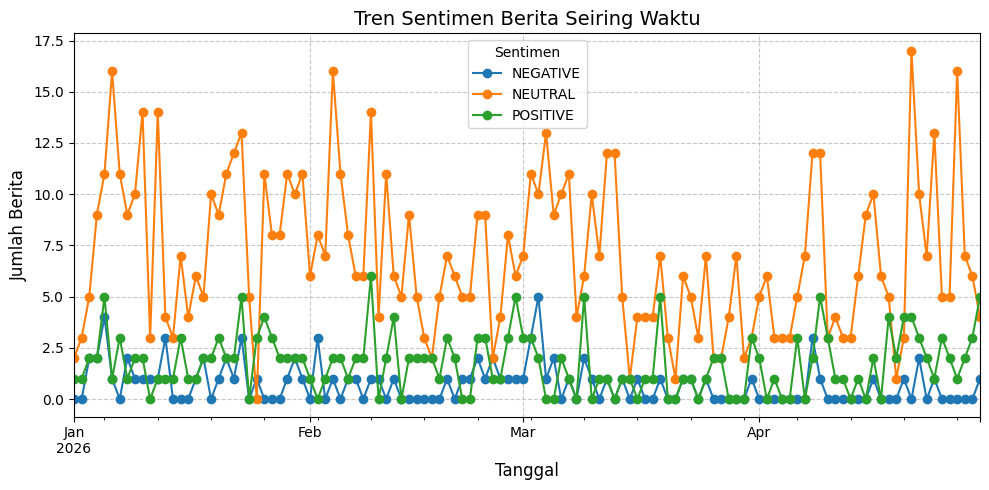

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%Y-%m-%d')


sentiment_trend = df.groupby(['Tanggal', 'sentimen']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sentiment_trend.plot(kind='line', marker='o', ax=plt.gca())

plt.title('Tren Sentimen Berita Seiring Waktu', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah Berita', fontsize=12)
plt.legend(title='Sentimen')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Machine Learning

#TFIDF


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#TFIDF
from sklearn.feature_extraction.text import TfidfVectorizer
# menghapus kata yang muncul kurang dari 2 kali
tfidf = TfidfVectorizer(min_df=2)
X_tfidf = tfidf.fit_transform(df['data_clean'])
len (tfidf.get_feature_names_out())

#Label Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Mengubah data sentimen jadi numerik
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['sentimen'])
#Sentiment
print(label_encoder.classes_)

In [ ]:
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping Label:", mapping)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [23]:
#Baseline model

#SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# 1. Inisialisasi SVM (SVC - Support Vector Classification)
model_svm = SVC(kernel='linear', random_state=42, class_weight='balanced')

# 2. Training Model
model_svm.fit(X_train, y_train)

# 3. Prediksi
y_pred_svm = model_svm.predict(X_test)

# 4. Evaluasi
print("--- Evaluasi SVM (Support Vector Machine) ---")
print(classification_report(y_test, y_pred_svm))

# Metrik spesifik
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")

--- Evaluasi SVM (Support Vector Machine) ---
              precision    recall  f1-score   support

           0       0.33      0.18      0.23        17
           1       0.84      0.87      0.85       168
           2       0.48      0.50      0.49        42

    accuracy                           0.75       227
   macro avg       0.55      0.52      0.52       227
weighted avg       0.73      0.75      0.74       227

Accuracy Score: 0.7489
F1 Score (Weighted): 0.7395


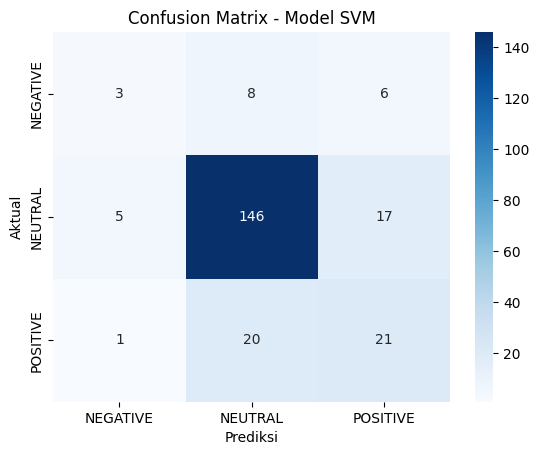

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Model SVM')
plt.show()

#Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score


# 1. Inisialisasi Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced' )

# 2. Training Model
model.fit(X_train, y_train)

# 3. Prediksi
y_pred = model.predict(X_test)

# 4. Evaluasi
print("--- Evaluasi Logistic Regression ---")
print(classification_report(y_test, y_pred))

# Metrik spesifik 
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

--- Evaluasi Logistic Regression ---
              precision    recall  f1-score   support

           0       0.29      0.24      0.26        17
           1       0.86      0.87      0.86       168
           2       0.49      0.50      0.49        42

    accuracy                           0.75       227
   macro avg       0.54      0.53      0.54       227
weighted avg       0.75      0.75      0.75       227

Accuracy Score: 0.7533
F1 Score (Weighted): 0.7501


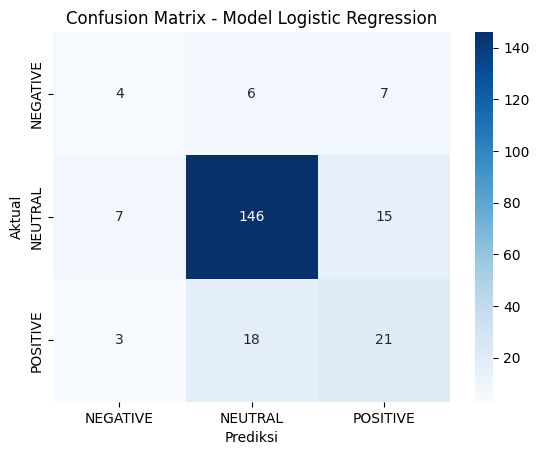

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Model Logistic Regression')
plt.show()

#Balancing Data

#Oversampling

In [28]:
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
from sklearn.preprocessing import StandardScaler

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

class_counts = pd.Series(y_resampled).value_counts()
print(class_counts)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

labels = label_encoder.classes_

plt.bar(class_counts.index, class_counts.values, color=['blue', 'green', 'red'])
plt.xticks(ticks=range(len(labels)), labels=labels)

plt.xlabel('Sentimen')
plt.ylabel('Jumlah (Count)')
plt.title('Distribusi Kelas Setelah Resampling (Oversampling)')
plt.show()

In [ ]:
# Train the model on the resampled data
model.fit(X_resampled, y_resampled)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 2. Training Model
model.fit(X_resampled, y_resampled)

# 3. Prediksi
y_pred_ros = model.predict(X_test)

# 4. Evaluasi
print("--- Evaluasi Random Over Sampling ---")
print(classification_report(y_test, y_pred_ros))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ros)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix ROS')
plt.show()

#Oversampling (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
# Assuming y_resampled is a Pandas Series
class_counts = pd.Series(y_resampled).value_counts()
print(class_counts)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# 2. Training Model
model.fit(X_resampled, y_resampled)

# 3. Prediksi
y_pred_smote = model.predict(X_test)

# 4. Evaluasi
print("--- Evaluasi SMOTE ---")
print(classification_report(y_test, y_pred_smote))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Buat Confusion Matrix
cm = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Validasi (smote)')
plt.show()

#Oversampling ADASYN

In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN
import pandas as pd


scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 


adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train_scaled, y_train)

In [ ]:
class_counts_ada = pd.Series(y_resampled).value_counts()
print("Jumlah kelas setelah ADASYN & Scaling:")
print(class_counts_ada)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_final = LogisticRegression(max_iter=1000, random_state=42)
model_final.fit(X_resampled, y_resampled)

y_pred_ada = model_final.predict(X_test_scaled)

print(classification_report(y_test, y_pred_ada))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Buat Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Validasi Adasyn')
plt.show()

#Undersampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd


undersample = RandomUnderSampler(random_state=42)

X_resampled_under, y_resampled_under = undersample.fit_resample(X_train, y_train)

class_counts_under = pd.Series(y_resampled_under).value_counts().sort_index()
print("Jumlah data setelah Undersampling:")
print(class_counts_under)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


model_under = LogisticRegression(max_iter=1000, random_state=42)

model_under.fit(X_resampled_under, y_resampled_under)

y_pred_under = model_under.predict(X_test)

print(classification_report(y_test, y_pred_under))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_under)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Validasi (undersample)')
plt.show()

#EditedNearestNeighbours

In [ ]:
from imblearn.under_sampling import EditedNearestNeighbours
import pandas as pd


enn = EditedNearestNeighbours()
X_resampled_enn, y_resampled_enn = enn.fit_resample(X_train, y_train)


class_counts_enn = pd.Series(y_resampled_enn).value_counts().sort_index()
print("Jumlah data setelah dibersihkan dengan ENN:")
print(class_counts_enn)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


model_enn = LogisticRegression(max_iter=1000, random_state=42)
model_enn.fit(X_resampled_enn, y_resampled_enn)

y_pred_enn = model_enn.predict(X_test)

print("\n--- Laporan Klasifikasi: ENN ---")
print(classification_report(y_test, y_pred_enn))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_enn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Validasi (undersample)')
plt.show()